# Logistic Regression and the influence of regularization

A smaller value of C leads to a more restricted model. The coefficient value will be smaller.
The model will generalize better.

**more regularization** -> simpler model, lower training accuracy
**less regularization** -> complex model, might overfit, high training accuracy, (almost always) higher test accuracy

L1 regularization (e.g. Lasso)
L2 regularization (e.g. Ridge)

In [53]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target)

In [54]:
from sklearn.linear_model import LogisticRegression

lr_weak = LogisticRegression(C=100)
lr_strong = LogisticRegression(C=0.01)

lr_weak.fit(X_train, y_train)
lr_strong.fit(X_train, y_train)

print("Weak training set score: {:.3f}".format(lr_weak.score(X_train, y_train)))
print("Strong training set score: {:.3f}".format(lr_strong.score(X_train, y_train)))

Weak training set score: 0.944
Strong training set score: 0.939


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

In [55]:
print("Weak test set score: {:.3f}".format(lr_weak.score(X_test, y_test)))
print("Strong test set score: {:.3f}".format(lr_strong.score(X_test, y_test)))

Weak test set score: 0.944
Strong test set score: 0.923


In [56]:
# L1 regularization (e.g. Lasso) vs. L2 regularization (e.g. Ridge)

lr_L1 = LogisticRegression(solver='liblinear', penalty='l1')
lr_L2 = LogisticRegression() # defaults to 'l2'

lr_L1.fit(X_train, y_train)
lr_L2.fit(X_train, y_train)

/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

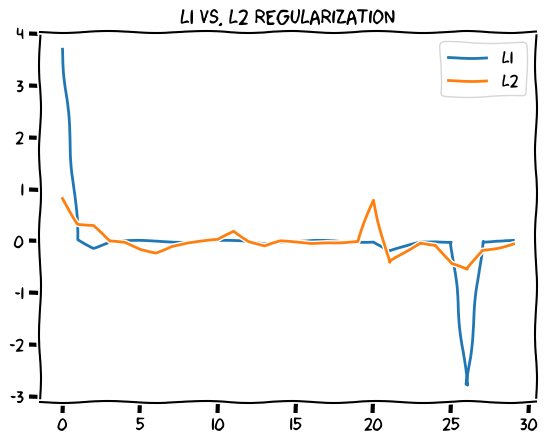

In [57]:
# Plot L1 vs. L2 regularization
import matplotlib.pyplot as plt
plt.xkcd()

plt.title("L1 vs. L2 regularization")
plt.plot(lr_L1.coef_.flatten(), label="L1")
plt.plot(lr_L2.coef_.flatten(), label="L2")
plt.legend()
plt.show()

> Note: L1 set a lot of coefficients to zero, L2 does not - performs kind of feature selection

In [58]:
# Create a Plot with different values of C

train_errs = list()
test_errs = list()

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for C_value in C_values:
    # Create LogisticRegression object and fit
    lr = LogisticRegression(C=C_value)
    lr.fit(X_train, y_train)

    train_errs.append( 1.0 - lr.score(X_train, y_train))
    test_errs.append( 1.0 - lr.score(X_test, y_test) )

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

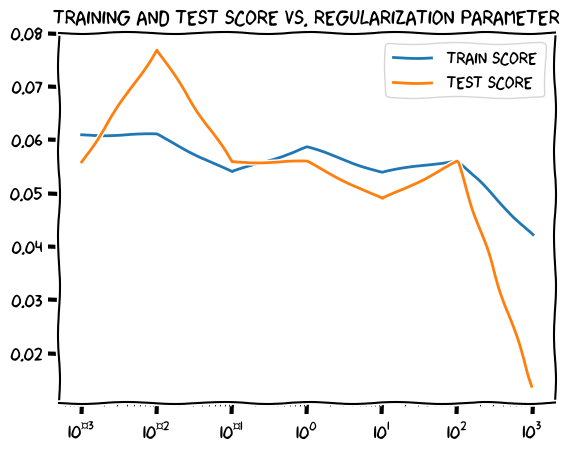

In [59]:
plt.title("Training and Test Score vs. Regularization Parameter")

plt.semilogx(C_values, train_errs, C_values, test_errs)
plt.legend(("train score", "test score"))
plt.show()

In [60]:
# Feature selection with L1 regularization in action
from sklearn.model_selection import GridSearchCV
import numpy as np

searcher = GridSearchCV(lr_L1, {'C':[0.001, 0.01, 0.1, 1, 10]})
searcher.fit(X_train, y_train)

print("Best C: {}".format(searcher.best_params_['C']))

best_lr = searcher.best_estimator_
coefs = best_lr.coef_
print("Total number of features:", coefs.size)
print("Number of selected features:", np.count_nonzero(coefs))

/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number 

Best C: 1
Total number of features: 30
Number of selected features: 9


/opt/homebrew/lib/python3.11/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Top 3 features: ['mean radius' 'mean texture' 'compactness error']


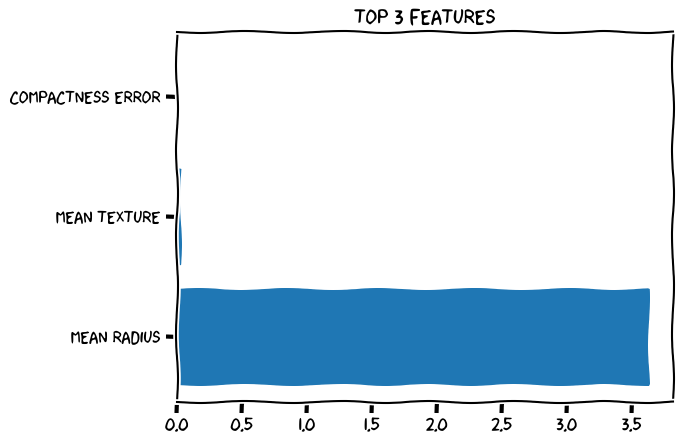

In [62]:
# Investigate the best performing model and it's coefficients

index = np.argsort(best_lr.coef_.flatten())
reversed_index = index[::-1]

print("Top 3 features: {}".format(dataset.feature_names[reversed_index[:3]]))

# Plot the coefficients
plt.title("Top 3 Features")
plt.barh(range(3), best_lr.coef_.flatten()[reversed_index[:3]])
plt.yticks(range(3), dataset.feature_names[reversed_index[:3]])
plt.show()